<a href="https://colab.research.google.com/github/Ajwad07/ML_projects_/blob/main/Memotion_GAN_trial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [ ]:
!kaggle datasets download -d williamscott701/memotion-dataset-7k

! unzip "memotion-dataset-7k.zip"

Streaming output truncated to the last 5000 lines.
  inflating: memotion_dataset_7k/images/image_2798.png  
  inflating: memotion_dataset_7k/images/image_2799.png  
  inflating: memotion_dataset_7k/images/image_28.jpg  
  inflating: memotion_dataset_7k/images/image_280.jpg  
  inflating: memotion_dataset_7k/images/image_2800.png  
  inflating: memotion_dataset_7k/images/image_2801.png  
  inflating: memotion_dataset_7k/images/image_2802.png  
  inflating: memotion_dataset_7k/images/image_2803.png  
  inflating: memotion_dataset_7k/images/image_2804.png  
  inflating: memotion_dataset_7k/images/image_2805.jpg  
  inflating: memotion_dataset_7k/images/image_2806.jpg  
  inflating: memotion_dataset_7k/images/image_2807.jpg  
  inflating: memotion_dataset_7k/images/image_2808.jpg  
  inflating: memotion_dataset_7k/images/image_2809.png  
  inflating: memotion_dataset_7k/images/image_281.png  
  inflating: memotion_dataset_7k/images/image_2810.jpg  
  inflating: memotion_dataset_7k/images/i

In [ ]:
device='cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets, utils
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [ ]:
class MemotionDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file).dropna(subset=['overall_sentiment'])
        self.df = self.df.sample(1000, random_state=42).reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.le = LabelEncoder()
        self.df['label'] = self.le.fit_transform(self.df['overall_sentiment'])
        self.num_classes = len(self.le.classes_)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_name'])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row['label'], dtype=torch.long)
        return image, label

# Transforms
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Create dataset
dataset = MemotionDataset(
    csv_file='/content/memotion_dataset_7k/labels.csv',
    img_dir='/content/memotion_dataset_7k/images',
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)
num_classes = dataset.num_classes


In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim, label_dim, img_channels):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(label_dim, label_dim)

        self.net = nn.Sequential(
            nn.Linear(noise_dim + label_dim, 256*8*8),
            nn.BatchNorm1d(256*8*8),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 8, 8)),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, img_channels, 4, 2, 1),  # 64x64
            nn.Tanh()
        )

    def forward(self, noise, labels):
        labels = self.label_emb(labels)
        x = torch.cat([noise, labels], dim=1)
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self, label_dim, img_channels):
        super(Discriminator, self).__init__()
        self.label_emb = nn.Embedding(label_dim, label_dim)

        self.net = nn.Sequential(
            nn.Conv2d(img_channels + 1, 64, 4, 2, 1),  # 32x32
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),  # 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(256*8*8, 1),
            nn.Sigmoid()
        )

    def forward(self, imgs, labels):
        labels = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        label_map = labels.expand(labels.size(0), labels.size(1), 64, 64)
        x = torch.cat([imgs, label_map[:, :1]], dim=1)
        return self.net(x)


In [ ]:
generator=Generator(noise_dim=100, label_dim=num_classes, img_channels=3).to(device)
discriminator=Discriminator(label_dim=num_classes, img_channels=3).to(device)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
noise_dim = 100
generator = Generator(noise_dim, num_classes, 3).to(device)
discriminator = Discriminator(num_classes, 3).to(device)

g_opt = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()
d_losses = []
g_losses = []

noise_dim = 100
for epoch in range(30):
    epoch_d_loss = 0
    epoch_g_loss = 0
    steps = 0

    for real_imgs, labels in loader:
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)
        steps += 1

        # === Discriminator ===
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = generator(noise, labels)
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        d_real = discriminator(real_imgs, labels)
        d_fake = discriminator(fake_imgs.detach(), labels)
        d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # === Generator ===
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = generator(noise, labels)
        g_loss = criterion(discriminator(fake_imgs, labels), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    # ✅ Append once per epoch
    d_losses.append(epoch_d_loss / steps)
    g_losses.append(epoch_g_loss / steps)

    print(f"[Epoch {epoch+1}] D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")


[Epoch 1] D Loss: 0.9421 | G Loss: 2.0587
[Epoch 2] D Loss: 0.3051 | G Loss: 4.1785
[Epoch 3] D Loss: 0.1035 | G Loss: 5.1053
[Epoch 4] D Loss: 0.0719 | G Loss: 5.6322
[Epoch 5] D Loss: 0.0509 | G Loss: 6.0432
[Epoch 6] D Loss: 0.3110 | G Loss: 5.7451
[Epoch 7] D Loss: 0.9176 | G Loss: 3.9604
[Epoch 8] D Loss: 0.8639 | G Loss: 3.2534
[Epoch 9] D Loss: 0.9055 | G Loss: 3.0036
[Epoch 10] D Loss: 0.8024 | G Loss: 3.1199
[Epoch 11] D Loss: 0.7393 | G Loss: 3.1809
[Epoch 12] D Loss: 0.4806 | G Loss: 4.1080
[Epoch 13] D Loss: 0.5139 | G Loss: 4.2426
[Epoch 14] D Loss: 0.5371 | G Loss: 4.0040
[Epoch 15] D Loss: 0.3390 | G Loss: 4.7216
[Epoch 16] D Loss: 0.4049 | G Loss: 4.5866
[Epoch 17] D Loss: 0.3304 | G Loss: 4.6410
[Epoch 18] D Loss: 0.8283 | G Loss: 4.2667
[Epoch 19] D Loss: 0.8286 | G Loss: 2.9912
[Epoch 20] D Loss: 0.6547 | G Loss: 3.5064
[Epoch 21] D Loss: 0.4110 | G Loss: 3.4942
[Epoch 22] D Loss: 0.4133 | G Loss: 3.7481
[Epoch 23] D Loss: 0.3575 | G Loss: 3.9237
[Epoch 24] D Loss: 0

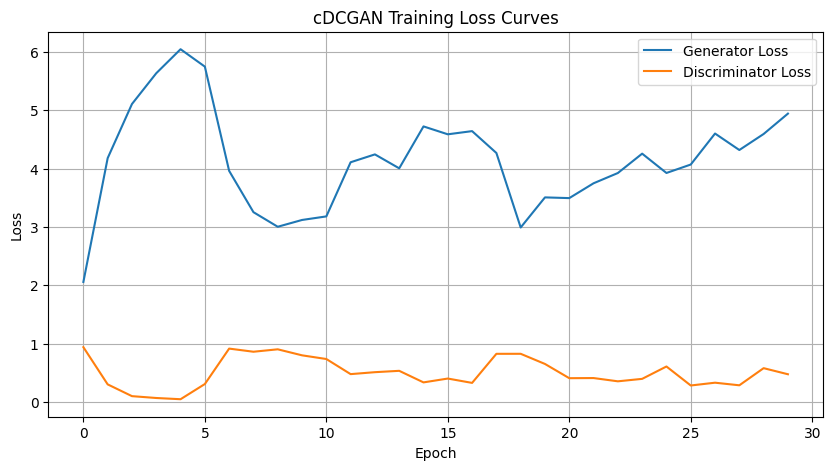

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("cDCGAN Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def show_generated(label_text):
    generator.eval()
    label_idx = dataset.le.transform([label_text])[0]
    label = torch.tensor([label_idx]*10).to(device)
    noise = torch.randn(10, noise_dim).to(device)
    with torch.no_grad():
        gen_imgs = generator(noise, label)
    gen_imgs = (gen_imgs + 1) / 2
    grid = utils.make_grid(gen_imgs.cpu(), nrow=5)
    plt.figure(figsize=(10, 2))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.title(f"Generated: {label_text}")
    plt.show()


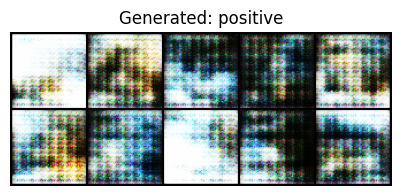

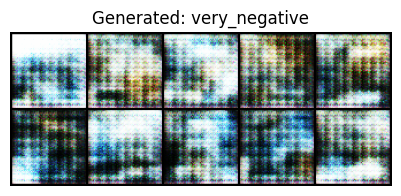

In [ ]:
show_generated("positive")
show_generated("very_negative")


### **WIth label smoothing**


```
# This is formatted as code
```



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
noise_dim = 100
generator = Generator(noise_dim, num_classes, 3).to(device)
discriminator = Discriminator(num_classes, 3).to(device)

g_opt = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()
d_losses = []
g_losses = []

noise_dim = 100
for epoch in range(30):
    epoch_d_loss = 0
    epoch_g_loss = 0
    steps = 0

    for real_imgs, labels in loader:
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)
        steps += 1

        # === Discriminator ===
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = generator(noise, labels)
        real_labels = torch.ones(batch_size, 1).to(device)*0.9  #changed here
        fake_labels = torch.zeros(batch_size, 1).to(device)+1 #changed here

        d_real = discriminator(real_imgs, labels)
        d_fake = discriminator(fake_imgs.detach(), labels)
        d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # === Generator ===
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = generator(noise, labels)
        g_loss = criterion(discriminator(fake_imgs, labels), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    # ✅ Append once per epoch
    d_losses.append(epoch_d_loss / steps)
    g_losses.append(epoch_g_loss / steps)

    print(f"[Epoch {epoch+1}] D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")


[Epoch 1] D Loss: 0.4521 | G Loss: 0.3958
[Epoch 2] D Loss: 0.3627 | G Loss: 0.4466
[Epoch 3] D Loss: 0.3499 | G Loss: 0.4714
[Epoch 4] D Loss: 0.3656 | G Loss: 0.4280
[Epoch 5] D Loss: 0.3838 | G Loss: 0.4095
[Epoch 6] D Loss: 0.3880 | G Loss: 0.4083
[Epoch 7] D Loss: 0.3875 | G Loss: 0.4002
[Epoch 8] D Loss: 0.3827 | G Loss: 0.4135
[Epoch 9] D Loss: 0.3814 | G Loss: 0.4220
[Epoch 10] D Loss: 0.3745 | G Loss: 0.4286
[Epoch 11] D Loss: 0.3681 | G Loss: 0.4271
[Epoch 12] D Loss: 0.3655 | G Loss: 0.4553
[Epoch 13] D Loss: 0.3644 | G Loss: 0.4711
[Epoch 14] D Loss: 0.3763 | G Loss: 0.4677
[Epoch 15] D Loss: 0.3628 | G Loss: 0.4586
[Epoch 16] D Loss: 0.3754 | G Loss: 0.4336
[Epoch 17] D Loss: 0.3710 | G Loss: 0.4346
[Epoch 18] D Loss: 0.3659 | G Loss: 0.4508
[Epoch 19] D Loss: 0.3679 | G Loss: 0.4600
[Epoch 20] D Loss: 0.3611 | G Loss: 0.4610
[Epoch 21] D Loss: 0.3590 | G Loss: 0.4663
[Epoch 22] D Loss: 0.3659 | G Loss: 0.4368
[Epoch 23] D Loss: 0.3664 | G Loss: 0.4481
[Epoch 24] D Loss: 0

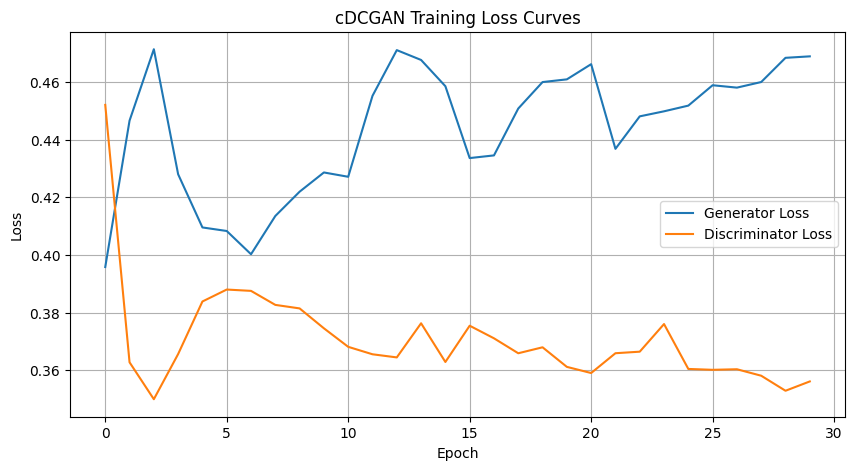

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("cDCGAN Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def show_generated(label_text):
    generator.eval()
    label_idx = dataset.le.transform([label_text])[0]
    label = torch.tensor([label_idx]*10).to(device)
    noise = torch.randn(10, noise_dim).to(device)
    with torch.no_grad():
        gen_imgs = generator(noise, label)
    gen_imgs = (gen_imgs + 1) / 2
    grid = utils.make_grid(gen_imgs.cpu(), nrow=5)
    plt.figure(figsize=(10, 2))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.title(f"Generated: {label_text}")
    plt.show()

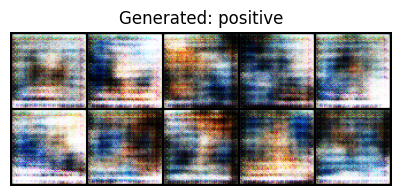

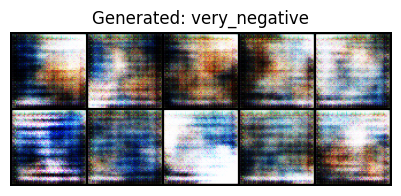

In [ ]:
show_generated("positive")
show_generated("very_negative")


## **Full Label Embedding in Discriminator (C-channel conditioning)**
🧠 What it is:
Instead of using only 1 channel from the label embedding, use the full vector and expand it across the image dimensions.

🔁 Modify your Discriminator’s forward():
```
def forward(self, imgs, labels):
    labels = self.label_emb(labels)  # [B, C]
    label_map = labels.unsqueeze(2).unsqueeze(3)  # [B, C, 1, 1]
    label_map = label_map.expand(-1, -1, 64, 64)  # [B, C, 64, 64]
    x = torch.cat([imgs, label_map], dim=1)      # concat with image channels
    return self.net(x)
```
Also, in the constructor (__init__()), update the first Conv2d:

```
self.net = nn.Sequential(
    nn.Conv2d(img_channels + label_dim, 64, 4, 2, 1),  # not +1
    ...
)
```
This gives the Discriminator full access to the condition.

In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim, label_dim, img_channels):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(label_dim, label_dim)

        self.net = nn.Sequential(
            nn.Linear(noise_dim + label_dim, 256*8*8),
            nn.BatchNorm1d(256*8*8),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 8, 8)),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, img_channels, 4, 2, 1),  # 64x64
            nn.Tanh()
        )

    def forward(self, noise, labels):
        labels = self.label_emb(labels)
        x = torch.cat([noise, labels], dim=1)
        return self.net(x)

class Discriminator_with_c_channel(nn.Module):
    def __init__(self, label_dim, img_channels):
        super(Discriminator_with_c_channel, self).__init__()
        self.label_emb = nn.Embedding(label_dim, label_dim)

        self.net = nn.Sequential(
            nn.Conv2d(img_channels + label_dim, 64, 4, 2, 1),  # 32x32
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),  # 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(256*8*8, 1),
            nn.Sigmoid()
        )

    def forward(self, imgs, labels):
      labels = self.label_emb(labels)  # [B, C]
      label_map = labels.unsqueeze(2).unsqueeze(3)  # [B, C, 1, 1]
      label_map = label_map.expand(-1, -1, 64, 64)  # [B, C, 64, 64]
      x = torch.cat([imgs, label_map], dim=1)      # concat with image channels
      return self.net(x)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
noise_dim = 100
generator = Generator(noise_dim, num_classes, 3).to(device)
discriminator = Discriminator_with_c_channel(num_classes, 3).to(device)

g_opt = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()
d_losses = []
g_losses = []

noise_dim = 100
for epoch in range(30):
    epoch_d_loss = 0
    epoch_g_loss = 0
    steps = 0

    for real_imgs, labels in loader:
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)
        steps += 1

        # === Discriminator ===
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = generator(noise, labels)
        real_labels = torch.ones(batch_size, 1).to(device)*0.9 #no label smoothing
        fake_labels = torch.zeros(batch_size, 1).to(device)+1 #no label smoothing
        d_real = discriminator(real_imgs, labels)
        d_fake = discriminator(fake_imgs.detach(), labels)
        d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # === Generator ===
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = generator(noise, labels)
        g_loss = criterion(discriminator(fake_imgs, labels), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    # ✅ Append once per epoch
    d_losses.append(epoch_d_loss / steps)
    g_losses.append(epoch_g_loss / steps)

    print(f"[Epoch {epoch+1}] D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")


[Epoch 1] D Loss: 0.4571 | G Loss: 0.3848
[Epoch 2] D Loss: 0.3566 | G Loss: 0.4412
[Epoch 3] D Loss: 0.3687 | G Loss: 0.4186
[Epoch 4] D Loss: 0.3916 | G Loss: 0.3911
[Epoch 5] D Loss: 0.4056 | G Loss: 0.3953
[Epoch 6] D Loss: 0.3950 | G Loss: 0.3954
[Epoch 7] D Loss: 0.3889 | G Loss: 0.3867
[Epoch 8] D Loss: 0.3893 | G Loss: 0.3876
[Epoch 9] D Loss: 0.3854 | G Loss: 0.3935
[Epoch 10] D Loss: 0.3823 | G Loss: 0.3978
[Epoch 11] D Loss: 0.3777 | G Loss: 0.4135
[Epoch 12] D Loss: 0.3730 | G Loss: 0.4464
[Epoch 13] D Loss: 0.3776 | G Loss: 0.4372
[Epoch 14] D Loss: 0.3704 | G Loss: 0.4595
[Epoch 15] D Loss: 0.3642 | G Loss: 0.4582
[Epoch 16] D Loss: 0.3510 | G Loss: 0.4939
[Epoch 17] D Loss: 0.3607 | G Loss: 0.4754
[Epoch 18] D Loss: 0.3559 | G Loss: 0.4780
[Epoch 19] D Loss: 0.3529 | G Loss: 0.5018
[Epoch 20] D Loss: 0.3760 | G Loss: 0.4997
[Epoch 21] D Loss: 0.3539 | G Loss: 0.4802
[Epoch 22] D Loss: 0.3616 | G Loss: 0.4975
[Epoch 23] D Loss: 0.3629 | G Loss: 0.4488
[Epoch 24] D Loss: 0

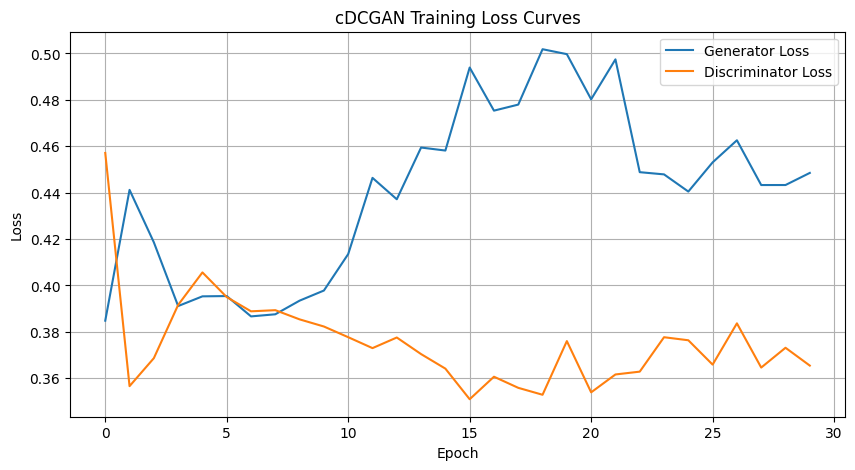

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("cDCGAN Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()


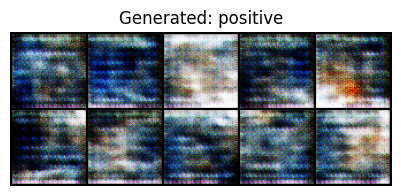

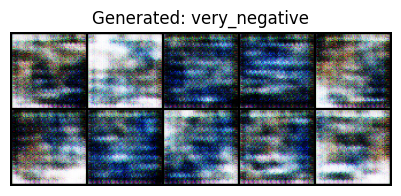

In [ ]:
show_generated("positive")
show_generated("very_negative")

### Better Generator Conditioning (Multiplicative)
🧠 What it is:
Instead of simply concatenating noise and label, interact them.

🧩 Modify Generator class:
```
1. In __init__():
self.label_proj = nn.Linear(label_dim, noise_dim)
```
```
2. In forward():

label_vec = self.label_proj(self.label_emb(labels))
x = noise * label_vec  # element-wise interaction
return self.net(x)
```
This lets noise behave differently per class.

In [ ]:

class Generator_multiplicative_conditoning(nn.Module):
    def __init__(self, noise_dim, label_dim, img_channels):
        super(Generator_multiplicative_conditoning, self).__init__()
        self.noise_dim = noise_dim
        self.label_dim = label_dim
        self.img_channels = img_channels

        # Label embedding
        self.label_emb = nn.Embedding(label_dim, label_dim)
        self.label_proj = nn.Linear(label_dim, noise_dim)

        # Generator network
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256*8*8),
            nn.BatchNorm1d(256*8*8),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 8, 8)),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, img_channels, 4, 2, 1),  # 64x64
            nn.Tanh()
        )

    def forward(self, noise, labels):
        # Embed and project labels
        embedded_labels = self.label_emb(labels)                # [B, label_dim]
        projected_labels = self.label_proj(embedded_labels)     # [B, noise_dim]

        # Element-wise multiply noise and projected labels
        conditioned_input = noise * projected_labels            # [B, noise_dim]

        return self.net(conditioned_input)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
noise_dim = 100
generator = Generator_multiplicative_conditoning(noise_dim, num_classes, 3).to(device)
discriminator = Discriminator(num_classes, 3).to(device)

g_opt = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()
d_losses = []
g_losses = []

noise_dim = 100
for epoch in range(30):
    epoch_d_loss = 0
    epoch_g_loss = 0
    steps = 0

    for real_imgs, labels in loader:
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)
        steps += 1

        # === Discriminator ===
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = generator(noise, labels)
        real_labels = torch.ones(batch_size, 1).to(device)*0.9 #no label smoothing
        fake_labels = torch.zeros(batch_size, 1).to(device)+1 #no label smoothing
        d_real = discriminator(real_imgs, labels)
        d_fake = discriminator(fake_imgs.detach(), labels)
        d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # === Generator ===
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = generator(noise, labels)
        g_loss = criterion(discriminator(fake_imgs, labels), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    # ✅ Append once per epoch
    d_losses.append(epoch_d_loss / steps)
    g_losses.append(epoch_g_loss / steps)

    print(f"[Epoch {epoch+1}] D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")


[Epoch 1] D Loss: 0.4673 | G Loss: 0.3859
[Epoch 2] D Loss: 0.3755 | G Loss: 0.4401
[Epoch 3] D Loss: 0.3681 | G Loss: 0.4581
[Epoch 4] D Loss: 0.3708 | G Loss: 0.4434
[Epoch 5] D Loss: 0.3700 | G Loss: 0.4481
[Epoch 6] D Loss: 0.3624 | G Loss: 0.4575
[Epoch 7] D Loss: 0.3617 | G Loss: 0.4506
[Epoch 8] D Loss: 0.3606 | G Loss: 0.4541
[Epoch 9] D Loss: 0.3613 | G Loss: 0.4469
[Epoch 10] D Loss: 0.3618 | G Loss: 0.4588
[Epoch 11] D Loss: 0.3741 | G Loss: 0.4337
[Epoch 12] D Loss: 0.3707 | G Loss: 0.4384
[Epoch 13] D Loss: 0.3675 | G Loss: 0.4379
[Epoch 14] D Loss: 0.3697 | G Loss: 0.4386
[Epoch 15] D Loss: 0.3659 | G Loss: 0.4542
[Epoch 16] D Loss: 0.3607 | G Loss: 0.4727
[Epoch 17] D Loss: 0.3602 | G Loss: 0.4623
[Epoch 18] D Loss: 0.3558 | G Loss: 0.4690
[Epoch 19] D Loss: 0.3687 | G Loss: 0.4712
[Epoch 20] D Loss: 0.3630 | G Loss: 0.4647
[Epoch 21] D Loss: 0.3649 | G Loss: 0.4512
[Epoch 22] D Loss: 0.3612 | G Loss: 0.4602
[Epoch 23] D Loss: 0.3674 | G Loss: 0.4458
[Epoch 24] D Loss: 0

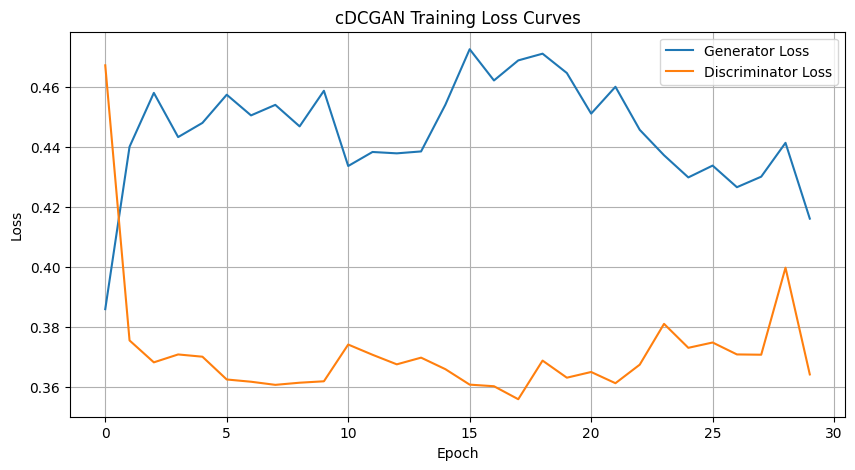

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("cDCGAN Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()


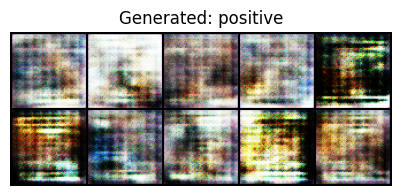

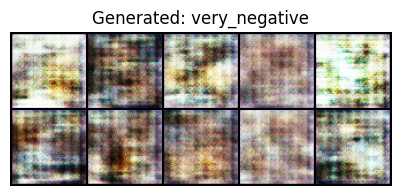

In [ ]:
show_generated("positive")
show_generated("very_negative")

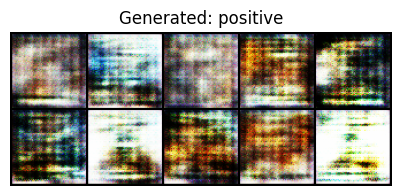

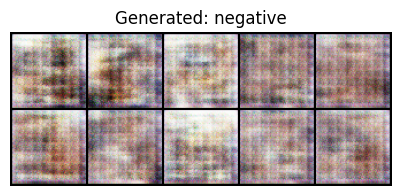

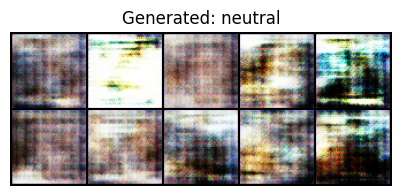

In [ ]:
show_generated("positive")
show_generated("negative")
show_generated("neutral")


## same but enhanced controlled output

[Epoch 1/100] D Loss: 1.0710 | G Loss: 1.7666


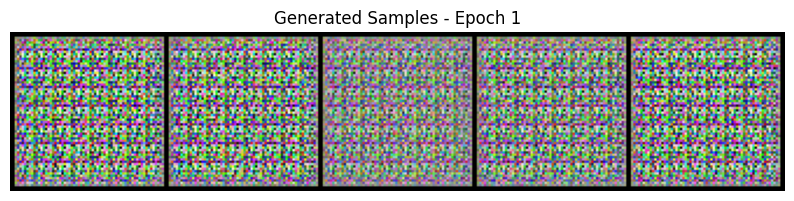

[Epoch 2/100] D Loss: 0.8006 | G Loss: 3.1489
[Epoch 3/100] D Loss: 0.7541 | G Loss: 2.7730
[Epoch 4/100] D Loss: 0.7964 | G Loss: 2.6737
[Epoch 5/100] D Loss: 0.8535 | G Loss: 2.4889
[Epoch 6/100] D Loss: 0.8328 | G Loss: 2.0741
[Epoch 7/100] D Loss: 0.9272 | G Loss: 2.1462
[Epoch 8/100] D Loss: 1.0062 | G Loss: 1.8658
[Epoch 9/100] D Loss: 1.0267 | G Loss: 1.5300
[Epoch 10/100] D Loss: 1.0309 | G Loss: 1.5998


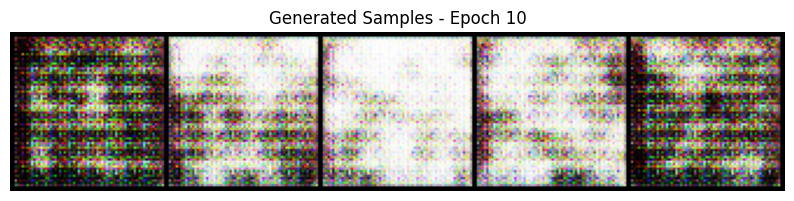

[Epoch 11/100] D Loss: 0.8859 | G Loss: 2.0478
[Epoch 12/100] D Loss: 1.0907 | G Loss: 1.8100
[Epoch 13/100] D Loss: 1.1793 | G Loss: 1.7185
[Epoch 14/100] D Loss: 1.0582 | G Loss: 1.6021
[Epoch 15/100] D Loss: 1.2433 | G Loss: 1.6182
[Epoch 16/100] D Loss: 1.0884 | G Loss: 1.4913
[Epoch 17/100] D Loss: 1.1016 | G Loss: 1.5398
[Epoch 18/100] D Loss: 1.1156 | G Loss: 1.5926
[Epoch 19/100] D Loss: 1.0646 | G Loss: 1.7765
[Epoch 20/100] D Loss: 1.1316 | G Loss: 1.6856


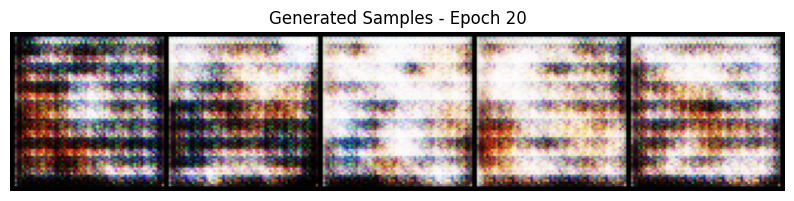

[Epoch 21/100] D Loss: 0.8878 | G Loss: 1.9019
[Epoch 22/100] D Loss: 1.0656 | G Loss: 1.9866
[Epoch 23/100] D Loss: 0.9616 | G Loss: 1.9619
[Epoch 24/100] D Loss: 0.8529 | G Loss: 2.1897
[Epoch 25/100] D Loss: 0.9976 | G Loss: 1.8666
[Epoch 26/100] D Loss: 0.9181 | G Loss: 1.8770
[Epoch 27/100] D Loss: 0.8501 | G Loss: 2.1304
[Epoch 28/100] D Loss: 0.9373 | G Loss: 2.0527
[Epoch 29/100] D Loss: 1.0322 | G Loss: 1.8962
[Epoch 30/100] D Loss: 0.9210 | G Loss: 2.0565


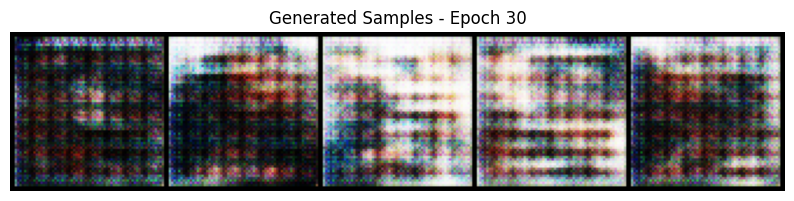

[Epoch 31/100] D Loss: 0.8687 | G Loss: 1.9896
[Epoch 32/100] D Loss: 0.8693 | G Loss: 2.3186
[Epoch 33/100] D Loss: 0.9180 | G Loss: 2.2587
[Epoch 34/100] D Loss: 0.9816 | G Loss: 2.0086
[Epoch 35/100] D Loss: 0.8098 | G Loss: 1.9597
[Epoch 36/100] D Loss: 0.9319 | G Loss: 2.0047
[Epoch 37/100] D Loss: 0.8535 | G Loss: 2.0388
[Epoch 38/100] D Loss: 1.1436 | G Loss: 2.2119
[Epoch 39/100] D Loss: 1.0278 | G Loss: 1.8573
[Epoch 40/100] D Loss: 1.0235 | G Loss: 1.7790


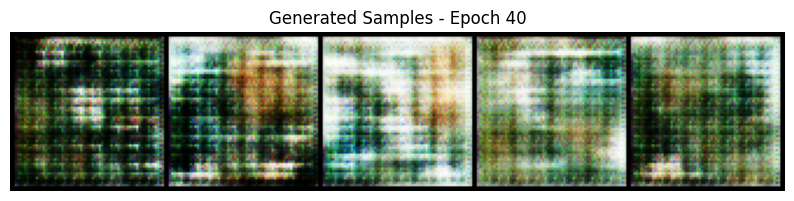

[Epoch 41/100] D Loss: 1.0834 | G Loss: 1.7735
[Epoch 42/100] D Loss: 0.9833 | G Loss: 1.6456
[Epoch 43/100] D Loss: 1.0804 | G Loss: 1.6969
[Epoch 44/100] D Loss: 0.9528 | G Loss: 1.7148
[Epoch 45/100] D Loss: 0.9608 | G Loss: 1.7878
[Epoch 46/100] D Loss: 1.0129 | G Loss: 1.7554
[Epoch 47/100] D Loss: 0.9877 | G Loss: 1.6207
[Epoch 48/100] D Loss: 0.9947 | G Loss: 1.5832
[Epoch 49/100] D Loss: 0.8974 | G Loss: 1.7504
[Epoch 50/100] D Loss: 1.0682 | G Loss: 1.8368


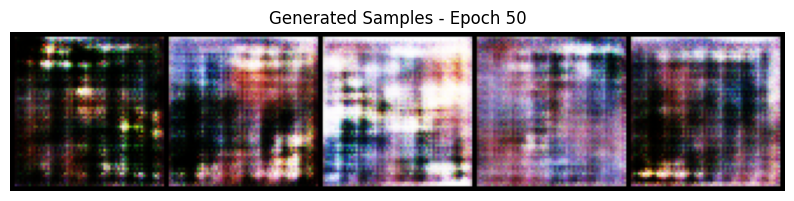

[Epoch 51/100] D Loss: 0.8519 | G Loss: 1.5333
[Epoch 52/100] D Loss: 0.8756 | G Loss: 1.4986
[Epoch 53/100] D Loss: 0.8384 | G Loss: 1.5468
[Epoch 54/100] D Loss: 0.8444 | G Loss: 1.5267
[Epoch 55/100] D Loss: 0.8239 | G Loss: 1.5791
[Epoch 56/100] D Loss: 0.8499 | G Loss: 1.5238
[Epoch 57/100] D Loss: 0.8203 | G Loss: 1.5997
[Epoch 58/100] D Loss: 0.8569 | G Loss: 1.6952
[Epoch 59/100] D Loss: 0.7989 | G Loss: 1.7536
[Epoch 60/100] D Loss: 0.8066 | G Loss: 1.8640


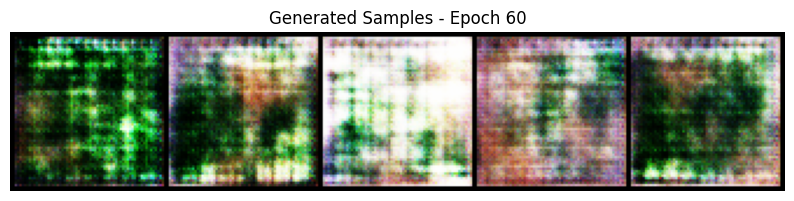

[Epoch 61/100] D Loss: 0.7498 | G Loss: 1.8927
[Epoch 62/100] D Loss: 0.8442 | G Loss: 1.8027
[Epoch 63/100] D Loss: 0.8680 | G Loss: 1.6570
[Epoch 64/100] D Loss: 0.8741 | G Loss: 1.6537
[Epoch 65/100] D Loss: 0.8477 | G Loss: 1.7412
[Epoch 66/100] D Loss: 0.8361 | G Loss: 1.6710
[Epoch 67/100] D Loss: 0.8175 | G Loss: 1.7882
[Epoch 68/100] D Loss: 0.7842 | G Loss: 1.8356
[Epoch 69/100] D Loss: 0.8476 | G Loss: 1.7024
[Epoch 70/100] D Loss: 0.7768 | G Loss: 1.8583


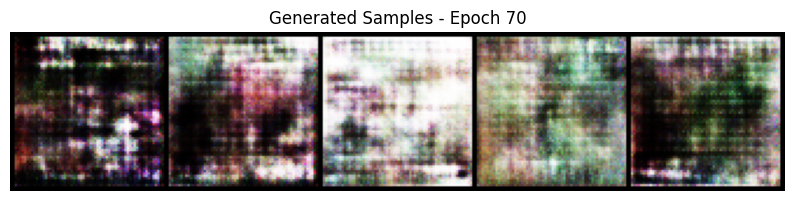

[Epoch 71/100] D Loss: 0.8075 | G Loss: 1.7770
[Epoch 72/100] D Loss: 0.8591 | G Loss: 1.7771
[Epoch 73/100] D Loss: 0.8255 | G Loss: 1.7412
[Epoch 74/100] D Loss: 0.9026 | G Loss: 1.8375
[Epoch 75/100] D Loss: 0.8462 | G Loss: 1.8488
[Epoch 76/100] D Loss: 0.8593 | G Loss: 1.6530
[Epoch 77/100] D Loss: 0.8449 | G Loss: 1.6760
[Epoch 78/100] D Loss: 0.8090 | G Loss: 1.7408
[Epoch 79/100] D Loss: 0.8504 | G Loss: 1.7270
[Epoch 80/100] D Loss: 0.8997 | G Loss: 1.7032


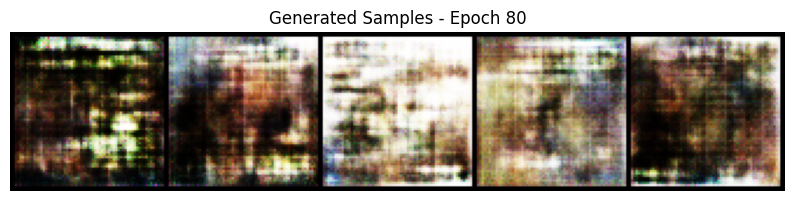

[Epoch 81/100] D Loss: 0.7936 | G Loss: 1.7757
[Epoch 82/100] D Loss: 0.8567 | G Loss: 1.7580
[Epoch 83/100] D Loss: 0.8019 | G Loss: 1.6102
[Epoch 84/100] D Loss: 0.7707 | G Loss: 1.7703
[Epoch 85/100] D Loss: 0.8062 | G Loss: 1.7875
[Epoch 86/100] D Loss: 0.8439 | G Loss: 1.7123
[Epoch 87/100] D Loss: 0.8536 | G Loss: 1.7355
[Epoch 88/100] D Loss: 0.9745 | G Loss: 1.8484
[Epoch 89/100] D Loss: 0.8028 | G Loss: 1.7721
[Epoch 90/100] D Loss: 0.8088 | G Loss: 1.7693


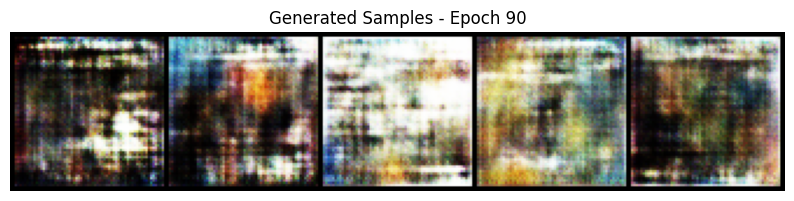

[Epoch 91/100] D Loss: 0.7864 | G Loss: 1.7619
[Epoch 92/100] D Loss: 0.7664 | G Loss: 1.8195
[Epoch 93/100] D Loss: 0.7413 | G Loss: 1.7784
[Epoch 94/100] D Loss: 0.7392 | G Loss: 1.8241
[Epoch 95/100] D Loss: 0.7649 | G Loss: 1.7470
[Epoch 96/100] D Loss: 0.7551 | G Loss: 1.8172
[Epoch 97/100] D Loss: 0.7989 | G Loss: 1.8584
[Epoch 98/100] D Loss: 0.7613 | G Loss: 1.8290
[Epoch 99/100] D Loss: 0.7439 | G Loss: 1.9294
[Epoch 100/100] D Loss: 0.7836 | G Loss: 1.9043


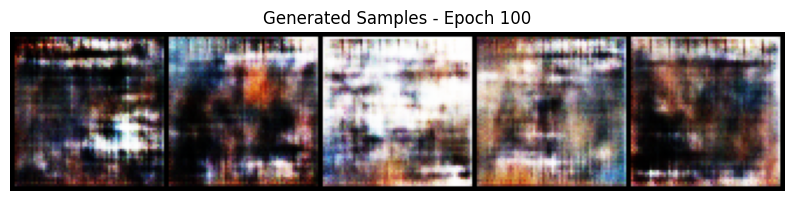

In [ ]:
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
import os

# Config
epochs = 100
save_every = 10
noise_dim = 100
num_classes = 5  # Update if different
img_channels = 3
img_size = 64

# Prepare output folder
os.makedirs("generated", exist_ok=True)

# Instantiate models
generator = Generator_multiplicative_conditoning(noise_dim, num_classes, img_channels).to(device)
discriminator = Discriminator(num_classes, img_channels).to(device)

g_opt = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

# Schedulers
g_sched = torch.optim.lr_scheduler.StepLR(g_opt, step_size=50, gamma=0.5)
d_sched = torch.optim.lr_scheduler.StepLR(d_opt, step_size=50, gamma=0.5)

criterion = nn.BCELoss()

# For plotting
g_losses = []
d_losses = []

# Fixed inputs for consistent generation visualization
fixed_noise = torch.randn(num_classes, noise_dim).to(device)
fixed_labels = torch.arange(0, num_classes).to(device)

# Training Loop
for epoch in range(epochs):
    generator.train()
    epoch_d_loss = 0
    epoch_g_loss = 0
    steps = 0

    for real_imgs, labels in loader:
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)
        steps += 1

        # === Discriminator ===
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = generator(noise, labels)
        real_labels = torch.ones(batch_size, 1).to(device) * 0.9
        fake_labels = torch.zeros(batch_size, 1).to(device) + 0.1

        d_real = discriminator(real_imgs, labels)
        d_fake = discriminator(fake_imgs.detach(), labels)
        d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # === Generator ===
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = generator(noise, labels)
        g_loss = criterion(discriminator(fake_imgs, labels), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    d_losses.append(epoch_d_loss / steps)
    g_losses.append(epoch_g_loss / steps)
    g_sched.step()
    d_sched.step()

    print(f"[Epoch {epoch+1}/{epochs}] D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")

    # === Inside the training loop ===
    if (epoch + 1) % save_every == 0 or epoch == 0:
        generator.eval()
        with torch.no_grad():
            fake_imgs = generator(fixed_noise, fixed_labels)
            fake_imgs = (fake_imgs + 1) / 2  # Rescale to [0, 1]

            grid = torchvision.utils.make_grid(fake_imgs.cpu(), nrow=num_classes)
            torchvision.utils.save_image(grid, f"generated/epoch_{epoch+1}.png")

            # ==== Show image inline ====
            np_grid = grid.permute(1, 2, 0).numpy()  # CHW -> HWC
            plt.figure(figsize=(10, 5))
            plt.imshow(np_grid)
            plt.axis("off")
            plt.title(f"Generated Samples - Epoch {epoch+1}")
            plt.show()



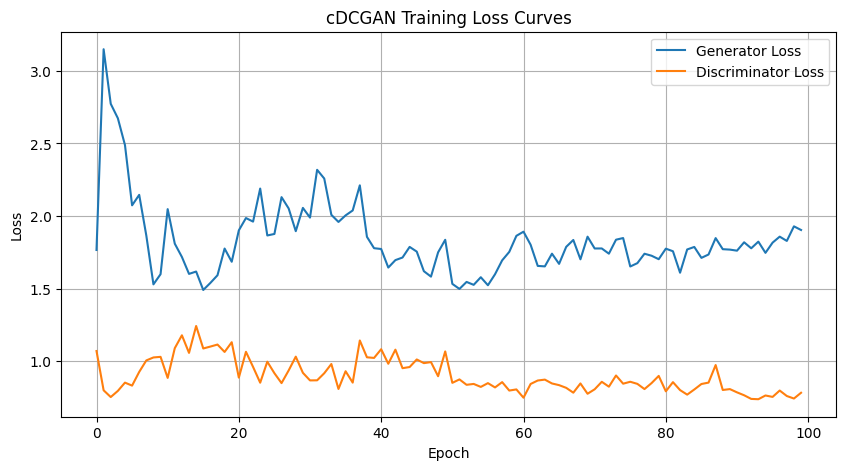

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("cDCGAN Training Loss Curves")
plt.legend()
plt.grid(True)
plt.savefig("generated/loss_plot.png")
plt.show()


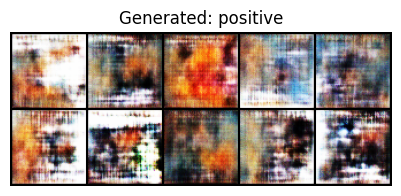

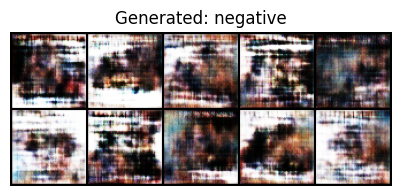

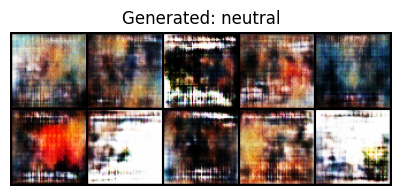

In [ ]:
show_generated("positive")
show_generated("negative")
show_generated("neutral")

